In [303]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
import joblib

In [289]:
df = pd.read_csv('train.csv')

In [290]:
df.drop(columns=['3SsnPorch', 'MiscVal', 'MoSold', 'Id', 'MSSubClass', 'OverallQual', 'BsmtFinSF2', 'LowQualFinSF', 'BsmtFullBath', 'YrSold', 'GarageArea', 'TotRmsAbvGrd', 'PoolQC', 'RoofMatl', 'Condition2', 'Utilities', 'Street'], inplace=True)

In [291]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

In [292]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [293]:
Cat_features = X.select_dtypes(include='object').columns.tolist()
Num_features = X.select_dtypes(include='number').columns.tolist()

In [294]:
Num_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', KNNImputer(n_neighbors=3)) 
])

In [295]:
Cat_pipeline = Pipeline([
    ('encoder', TargetEncoder()),
    ('scaler', StandardScaler()),
    ('imputer', KNNImputer(n_neighbors=3))
])

In [296]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Num_pipeline, Num_features),
        ('cat', Cat_pipeline, Cat_features)
    ]
)

In [297]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

In [298]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [299]:
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

In [300]:
print("Training Set Performance:")
print("Mean Absolute Error:", mean_absolute_error(y_train, y_train_pred))
print("Mean Squared Error:", mean_squared_error(y_train, y_train_pred))
print("Root Mean Squared Error:", root_mean_squared_error(y_train, y_train_pred))
print("R-squared:", r2_score(y_train, y_train_pred)*100)

Training Set Performance:
Mean Absolute Error: 18879.367993666976
Mean Squared Error: 896862434.666645
Root Mean Squared Error: 29947.661589290157
R-squared: 84.96345277410241


In [301]:
print("\nTest Set Performance:")
print("Mean Absolute Error:", mean_absolute_error(y_test, y_test_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_test_pred))
print("Root Mean Squared Error:", root_mean_squared_error(y_test, y_test_pred))
print("R-squared:", r2_score(y_test, y_test_pred)*100)


Test Set Performance:
Mean Absolute Error: 21126.21023843276
Mean Squared Error: 1129160272.4016175
Root Mean Squared Error: 33602.980111912955
R-squared: 85.27884940090826


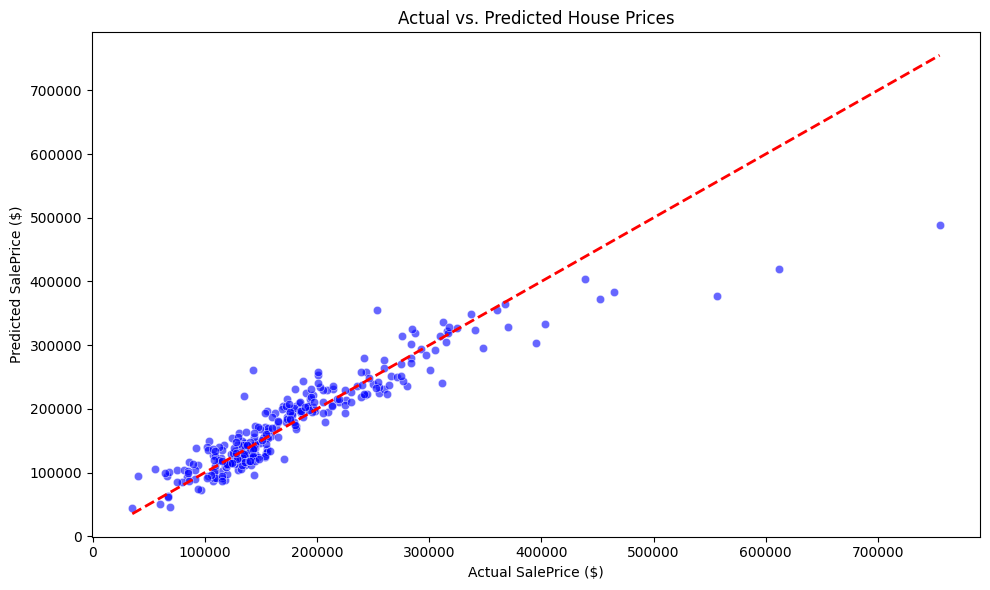

In [302]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.6, color='blue')

perfect_line = [y_test.min(), y_test.max()]
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', linewidth=2)

plt.title('Actual vs. Predicted House Prices')
plt.xlabel('Actual SalePrice ($)')
plt.ylabel('Predicted SalePrice ($)')
plt.tight_layout()
plt.show()

In [304]:
joblib.dump(pipeline, 'house_price_model.pkl')

['house_price_model.pkl']